# FIFO Auto-Sized Depth & Achieved FPS vs. `--dsr-ratio` / `--pbi-ratio`, Partition 2 (S12-dense, `_wm`)

Six MILP validation probes on the real S12-dense `nearest_upsample` 512x512
architecture, partition 2 only, from
`hardware/builds/S12_dense_nearest_upsample_512_hwsweep_partition2_wm/`
(`_wm` = warm-started checkpoint). Each `.onnx` graph under
`post_fifo_autosize_checkpoints/` has already been through FINN's real
FIFO-characterization/auto-sizing step, so every `StreamingFIFO_rtl` node's
`depth` attribute is the actual, hardware-realistic auto-sized value (not a
default placeholder), and every compute node (`MVAU_rtl`,
`ConvolutionInputGenerator_rtl`, `Thresholding_rtl`, ...) carries FINN's own
real `cycles_estimate` attribute from that same characterization pass -- this
is what makes the achieved-FPS analysis below possible without re-deriving a
cost model for the auto-fold control (see that section for why).

Five of the six share the SAME `MILP/finn_milp.py` joint bit+folding solve
(hard LUT/BRAM/DSP caps 0.9/0.9/0.95, `--force-dsp`, `--candidate-bits 4,6,8`,
100 MHz) with only `--dsr-ratio` / `--pbi-ratio` swept one at a time (the
other left `null`, i.e. unconstrained) -- confirmed programmatically below
from each run's own `run_args.json`, not assumed. The sixth
(`baseline_both_off_autofold`) reuses the `both_off` bit-widths but skips MILP
folding entirely in favor of FINN's own auto-fold (`step_apply_folding_config`
never runs -- see this build's `README.md`); it is **not** part of the
MILP-constraint family and is plotted only as a dashed reference line, never
as an "off" sweep point. Its own real folding choice is recorded in
`autofold_config_partition2.json` (FINN's `step_target_fps_parallelization`
output) -- see "Cross-checking the auto-fold control" below.

Investigations:
1. Total / mean / range FIFO depth vs. `--dsr-ratio` / `--pbi-ratio`,
   `both_off` as the unconstrained control (median dropped -- see that
   section), PLUS the same depths converted to total bits and BRAM18K-
   equivalent blocks (see "Converting FIFO depth to bits and BRAM18K-
   equivalent blocks").
2. **Achieved FPS** (and the bottleneck node driving it) vs. `--dsr-ratio` /
   `--pbi-ratio` -- added after the FIFO-depth result alone looked like the
   ratio constraint behaves as an on/off switch rather than a continuous
   dial; FPS is the other half of that story (see its own section for why).
3. A programmatic confirmation that all `--dsr-ratio`/`--pbi-ratio` sweep
   points share identical MILP constraints otherwise.
4. A cross-check of the auto-fold control's own real folding config
   (`autofold_config_partition2.json`) against the checkpoint's baked-in
   attributes, plus a from-scratch LUT/BRAM/DSP estimate for it using
   `MILP/utils/apply_folding_config_cost.py` -- a number FINN's own
   auto-fold never reports on its own (it only characterizes cycles, not
   resource usage, outside a full Vivado synth).
5. **Resource utilization (LUT / BRAM18K-compute / BRAM18K-FIFO / DSP %)
   vs. achieved FPS**, all six builds side by side -- what each build
   actually spends its budget on to get the FPS shown in investigation 2,
   with the FIFO buffering's own BRAM18K-equivalent cost (investigation 1)
   broken out as its own bar right next to the compute-side BRAM18K bar,
   since FIFO buffering and MVAU/weight-memory BRAM come from completely
   different sources and FIFO's share turns out NOT to be negligible.

X-axis order runs from most to least constrained (`1.5 -> 3.0 -> 5.0 -> Off`),
since `Off` is unconstrained -- the natural continuation past an ever-looser
ratio cap, not a fifth discrete "value" alongside the others. Each plot also
has an "-only" variant with the unconstrained `Off` control point dropped
entirely, zoomed in on just the constrained sweep itself.

Terminology: "DSR" = downstream-rate (chain-rate-coherence) ratio,
`--dsr-ratio`. "PBI" = parallel-branch-imbalance ratio, `--pbi-ratio` (see
`analysis/report/MILP/cross_sensitivity_dsr_pbi_sweep_v2.ipynb` for the full
naming history/correction -- no `--dpi-ratio` flag exists in `finn_milp.py`).


In [1]:
import json
from pathlib import Path
from statistics import mean, median

import onnx
import matplotlib.pyplot as plt

# Academic presentation, same house style as this folder's sibling notebook
# (cross_sensitivity_dsr_pbi_sweep_v2.ipynb).
plt.rcParams.update({
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelweight": "bold",
    "axes.labelsize": 11.5,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Fixed categorical order (dataviz skill's validated palette, slots 1-4):
# blue=mean, orange=median, aqua=range. Held constant across both figures so
# color always identifies the same statistic, never a rank/position.
COLOR_MEAN = "#2a78d6"
COLOR_MEDIAN = "#eb6834"
COLOR_RANGE = "#1baf7a"
COLOR_TOTAL = "#2a78d6"
COLOR_FPS = "#2a78d6"
COLOR_CYCLES = "#eb6834"
COLOR_AUTOFOLD = "#898781"  # muted grey -- reference line, not a sweep point
COLOR_LUT = "#2a78d6"
COLOR_BRAM = "#eb6834"
COLOR_BRAM_FIFO = "#eda100"  # palette slot 4 -- distinct from BRAM-compute (orange) and DSP (aqua)
COLOR_DSP = "#1baf7a"
COLOR_BITS = "#2a78d6"
COLOR_BRAM_EQUIV = "#eb6834"

CLOCK_MHZ = 100.0  # same target clock as the MILP solve and FIFO autosizing (see finn_milp.md)

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "MILP" / "finn_milp.py").is_file():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Could not locate repo root (MILP/finn_milp.py not found in any ancestor).")
    REPO_ROOT = REPO_ROOT.parent

BUILD_DIR = REPO_ROOT / "hardware" / "builds" / "S12_dense_nearest_upsample_512_hwsweep_partition2_wm"
CKPT_DIR = BUILD_DIR / "post_fifo_autosize_checkpoints"
MILP_DIR = REPO_ROOT / "MILP" / "artifacts" / "S12_dense_nearest_upsample_512_hwsweep_partition2_wm"
FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

import sys as _sys
_sys.path.insert(0, str(REPO_ROOT / "MILP"))
from finn_cost_model import _finn_buffer_bram18  # noqa: E402 -- pure per-buffer pricing primitive, see next section

print("Repo root:  ", REPO_ROOT)
print("Checkpoints:", CKPT_DIR)
print("MILP runs:  ", MILP_DIR)
print("Figures ->  ", FIG_DIR)


Repo root:   /workspace/LightM-UNet
Checkpoints: /workspace/LightM-UNet/hardware/builds/S12_dense_nearest_upsample_512_hwsweep_partition2_wm/post_fifo_autosize_checkpoints
MILP runs:   /workspace/LightM-UNet/MILP/artifacts/S12_dense_nearest_upsample_512_hwsweep_partition2_wm
Figures ->   /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures


## Extract auto-sized FIFO depths and per-node cycle estimates

Every `StreamingFIFO_rtl` node's `depth` attribute and every compute node's
`cycles_estimate` attribute are plain ONNX int attributes set by FINN's own
characterization pass -- read directly with the `onnx` protobuf API, no
FINN/QONNX runtime needed for this.


In [2]:
# tag -> (checkpoint filename, MILP run_args dir name or None for the
# non-MILP-folded autofold control, dsr_ratio, pbi_ratio, x-axis label)
CHECKPOINTS = {
    "both_off":  ("partition2_baseline_both_off_milpfold_prefifo_autosize.onnx",
                  "baseline_both_off", None, None, "Off"),
    "dsr1.5":    ("partition2_dsrSweep_pbiOff_dsr1.5_milpfold_prefifo_autosize.onnx",
                  "dsrSweep_pbiOff_dsr1.5", 1.5, None, "1.5"),
    "dsr3.0":    ("partition2_dsrSweep_pbiOff_dsr3.0_milpfold_prefifo_autosize.onnx",
                  "dsrSweep_pbiOff_dsr3.0", 3.0, None, "3.0"),
    "dsr5.0":    ("partition2_dsrSweep_pbiOff_dsr5.0_milpfold_prefifo_autosize.onnx",
                  "dsrSweep_pbiOff_dsr5.0", 5.0, None, "5.0"),
    "pbi1.5":    ("partition2_pbiSweep_dsrOff_pbi1.5_milpfold_prefifo_autosize.onnx",
                  "pbiSweep_dsrOff_pbi1.5", None, 1.5, "1.5"),
    "autofold_control": ("partition2_baseline_both_off_autofold_prefifo_autosize.onnx",
                          None, None, None, "Auto-fold (no MILP folding)"),
}


def extract_fifo_depths(onnx_path: Path) -> list[int]:
    m = onnx.load(str(onnx_path))
    depths = []
    for n in m.graph.node:
        if n.op_type.startswith("StreamingFIFO"):
            for a in n.attribute:
                if a.name == "depth":
                    depths.append(a.i)
    return depths


def extract_bottleneck(onnx_path: Path) -> dict:
    '''Max cycles_estimate over compute nodes (FIFOs excluded -- they read 0
    here, they are not throughput-determining dataflow stages). A streaming
    pipeline delivers one frame per slowest-node frame time (finn_milp.md,
    "Formulation"), so this max cycle count IS the network's achievable FPS
    at CLOCK_MHZ, for real hardware nodes actually present in this graph.'''
    m = onnx.load(str(onnx_path))
    best_cycles, best_op, best_name = 0, None, None
    for n in m.graph.node:
        if n.op_type.startswith("StreamingFIFO"):
            continue
        for a in n.attribute:
            if a.name == "cycles_estimate" and a.i > best_cycles:
                best_cycles, best_op, best_name = a.i, n.op_type, n.name
    return {"bottleneck_cycles": best_cycles, "bottleneck_op": best_op, "bottleneck_name": best_name,
            "fps": CLOCK_MHZ * 1e6 / best_cycles if best_cycles else float("nan")}


def depth_stats(depths: list[int]) -> dict:
    return {
        "n_fifos": len(depths),
        "total": sum(depths),
        "mean": mean(depths),
        "median": median(depths),
        "min": min(depths),
        "max": max(depths),
        "range": max(depths) - min(depths),
    }


stats = {}
for tag, (fname, _run_dir, dsr, pbi, xlabel) in CHECKPOINTS.items():
    onnx_path = CKPT_DIR / fname
    depths = extract_fifo_depths(onnx_path)
    s = depth_stats(depths)
    s.update(extract_bottleneck(onnx_path))
    s.update(tag=tag, dsr_ratio=dsr, pbi_ratio=pbi, x_label=xlabel)
    stats[tag] = s
    print(f"{tag:18s} n={s['n_fifos']:3d}  total={s['total']:7d}  mean={s['mean']:7.1f}  "
          f"range={s['range']:6d}  bottleneck={s['bottleneck_cycles']:8d} ({s['bottleneck_op']})  "
          f"FPS={s['fps']:7.2f}")


both_off           n= 96  total= 938961  mean= 9780.8  range=294910  bottleneck= 2359296 (MVAU_rtl)  FPS=  42.39
dsr1.5             n=105  total= 309532  mean= 2947.9  range=131070  bottleneck=  319752 (ConvolutionInputGenerator_rtl)  FPS= 312.74
dsr3.0             n=109  total= 309608  mean= 2840.4  range=131070  bottleneck=  319752 (ConvolutionInputGenerator_rtl)  FPS= 312.74
dsr5.0             n=109  total= 309641  mean= 2840.7  range=131070  bottleneck=  319752 (ConvolutionInputGenerator_rtl)  FPS= 312.74
pbi1.5             n=110  total= 309672  mean= 2815.2  range=131070  bottleneck=  319752 (ConvolutionInputGenerator_rtl)  FPS= 312.74
autofold_control   n= 96  total= 358712  mean= 3736.6  range=131070  bottleneck=  393216 (MVAU_rtl)  FPS= 254.31


## Converting FIFO depth to bits and BRAM18K-equivalent blocks

`depth` alone (words) isn't the real hardware cost -- a FIFO's actual memory
footprint is `depth x width_bits`, and `width_bits` is NOT the same for every
FIFO in this graph: it's `folded_shape[-1] x dtype_bits`, read straight off
each `StreamingFIFO_rtl` node's own `dataType` and `folded_shape` attributes
(FINN's own per-cycle transfer-width convention -- the last `folded_shape`
dim is however many parallel lanes that FIFO actually carries per cycle,
which can differ FIFO-to-FIFO even within the same graph depending on where
a DWC sits, e.g. one 8-bit lane vs eight 8-bit lanes = 64 bits/cycle).

Two numbers per FIFO from that:
- **Total bits** = `depth * width_bits` -- the raw information content, no
  packing efficiency assumed.
- **BRAM18K-equivalent blocks** via `_finn_buffer_bram18(width_bits, depth)`
  -- this repo's own port of FINN's UG573 SDP aspect-ratio table (see
  `finn_cost_model.py`, already reused for the SWU line buffer and weight-
  memory estimates elsewhere in this repo). **Caveat:** that table is
  calibrated against FINN's `ConvolutionInputGenerator_rtl.bram_estimation()`
  (a line buffer), not FINN's actual `StreamingFIFO.bram_estimation()` --
  no real per-FIFO BRAM calibration exists in this codebase yet (a known
  gap, same category as `finn_cost_model.md`'s other documented
  not-yet-modeled resources), so treat this as an informed
  aspect-ratio-aware estimate, not a validated one. A pure
  `ceil(total_bits / 18432)` theoretical-minimum-packing figure is reported
  alongside it for contrast -- the gap between the two is exactly the real
  aspect-ratio/cascading inefficiency the calibrated table accounts for and
  the naive minimum doesn't.


In [3]:
def _dtype_bits(dtype: str) -> int:
    s = dtype.upper()
    if s.startswith("UINT"):
        return int(s[4:])
    if s.startswith("INT"):
        return int(s[3:])
    raise ValueError(f"Unrecognized QONNX datatype string: {dtype!r}")


def extract_fifo_bits(onnx_path: Path) -> dict:
    m = onnx.load(str(onnx_path))
    total_bits, bram18k_est = 0, 0
    for n in m.graph.node:
        if n.op_type != "StreamingFIFO_rtl":
            continue
        attrs = {a.name: a for a in n.attribute}
        depth = attrs["depth"].i
        if depth == 0:
            continue
        dtype = attrs["dataType"].s.decode()
        folded_shape = list(attrs["folded_shape"].ints)
        width_bits = folded_shape[-1] * _dtype_bits(dtype)
        total_bits += depth * width_bits
        bram18k_est += _finn_buffer_bram18(width_bits, depth)
    return {
        "total_bits": total_bits, "bram18k_est": bram18k_est,
        "bram18k_theoretical_min": -(-total_bits // 18432),  # ceil division, 18432 bits = one BRAM18K block
    }


for tag, (fname, _run_dir, _dsr, _pbi, _xlabel) in CHECKPOINTS.items():
    stats[tag].update(extract_fifo_bits(CKPT_DIR / fname))
    s = stats[tag]
    print(f"{tag:18s} total_bits={s['total_bits']:9d}  bram18k_est={s['bram18k_est']:5d}  "
          f"theoretical_min={s['bram18k_theoretical_min']:5d}")


both_off           total_bits=  7802614  bram18k_est=  583  theoretical_min=  424


dsr1.5             total_bits=  2779332  bram18k_est=  350  theoretical_min=  151
dsr3.0             total_bits=  2780400  bram18k_est=  350  theoretical_min=  151
dsr5.0             total_bits=  2781364  bram18k_est=  357  theoretical_min=  151


pbi1.5             total_bits=  2782114  bram18k_est=  361  theoretical_min=  151
autofold_control   total_bits=  5144068  bram18k_est=  391  theoretical_min=  280


## Save the summary table

A small, flat summary (one row per checkpoint) -- plain `csv`, no `pandas`
needed for a table this size.


In [4]:
import csv

summary_csv = Path.cwd() / "partition2_fifo_depth_summary.csv"
fieldnames = ["tag", "dsr_ratio", "pbi_ratio", "n_fifos", "total", "mean", "median", "min", "max", "range",
              "total_bits", "bram18k_est", "bram18k_theoretical_min",
              "bottleneck_cycles", "bottleneck_op", "bottleneck_name", "fps"]
with open(summary_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    for tag in CHECKPOINTS:
        w.writerow({k: stats[tag][k] for k in fieldnames})
print(f"Wrote {summary_csv}")


Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/partition2_fifo_depth_summary.csv


## Confirm all sweep points share identical MILP constraints

Load each MILP-folded tag's own `run_args.json["shared_args"]`, strip the two
keys that are *meant* to differ (`dsr-ratio`, `pbi-ratio`), and assert the
remaining dict is byte-identical across all five. This is a real assertion,
not a visual eyeball -- it raises if any of LUT/BRAM/DSP caps, `force-dsp`,
`candidate-bits`, clock, time limit, etc. ever drift between sweep points.
(`autofold_control` has no `run_args.json` of its own -- it is not a MILP
solve at all, see the intro cell -- so it is excluded from this check.)


In [5]:
SWEPT_KEYS = {"dsr-ratio", "pbi-ratio"}

milp_tags = [tag for tag, (_, run_dir, _, _, _) in CHECKPOINTS.items() if run_dir is not None]
shared_args_by_tag = {}
for tag in milp_tags:
    run_dir = CHECKPOINTS[tag][1]
    with open(MILP_DIR / run_dir / "run_args.json") as f:
        run_args = json.load(f)
    shared = {k: v for k, v in run_args["shared_args"].items() if k not in SWEPT_KEYS}
    shared_args_by_tag[tag] = shared

reference_tag = milp_tags[0]
reference = shared_args_by_tag[reference_tag]
mismatches = []
for tag in milp_tags[1:]:
    if shared_args_by_tag[tag] != reference:
        diff = {k: (reference.get(k), shared_args_by_tag[tag].get(k))
                for k in reference if reference.get(k) != shared_args_by_tag[tag].get(k)}
        mismatches.append((tag, diff))

if mismatches:
    print("MISMATCH -- these tags differ from", reference_tag, "on non-swept args:")
    for tag, diff in mismatches:
        print(f"  {tag}: {diff}")
    raise AssertionError("MILP constraints are not identical across sweep points -- see printed diff above.")
else:
    print(f"CONFIRMED: all {len(milp_tags)} MILP-folded sweep points "
          f"({', '.join(milp_tags)}) share identical constraints (only "
          f"--dsr-ratio/--pbi-ratio differ):")
    for k, v in reference.items():
        print(f"  {k}: {v}")


CONFIRMED: all 5 MILP-folded sweep points (both_off, dsr1.5, dsr3.0, dsr5.0, pbi1.5) share identical constraints (only --dsr-ratio/--pbi-ratio differ):
  config: config_12_dense_relu_nearest_upsample
  sensitivity-file: MILP/artifacts/layer_sensitivity_12_dense_relu_nearest_upsample.json
  candidate-bits: 4,6,8
  hard-lut-fraction: 0.9
  hard-bram-fraction: 0.9
  hard-dsp-fraction: 0.95
  hard-uram-fraction: 1.0
  force-dsp: True
  max-latency-ms: None
  clock-mhz: 100.0
  target-fps: None
  force-serial: False
  require-simd-ge-pe: False
  allow-lut-mult: False
  time-limit: 600
  gap-rel: 0.02


## FIFO-depth plot helper

`plot_sweep` draws the two-panel FIFO-depth figure (total; mean/range on a
log axis -- median is dropped, it sits at the folding-minimum depth of 2 in
every config and carries no signal here, though it's still in the summary
CSV above). Called once per investigation, and a second time per
investigation with the unconstrained `Off` control point excluded, to zoom
in on just the constrained sweep itself.


In [6]:
def plot_sweep(tags_in_order, x_axis_title, out_path, fig_title):
    xs = [stats[t]["x_label"] for t in tags_in_order]
    totals = [stats[t]["total"] for t in tags_in_order]
    means = [stats[t]["mean"] for t in tags_in_order]
    ranges = [stats[t]["range"] for t in tags_in_order]
    af = stats["autofold_control"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

    axes[0].plot(xs, totals, marker="o", linewidth=2.5, markersize=8, color=COLOR_TOTAL, label="Total FIFO depth")
    axes[0].axhline(af["total"], color=COLOR_AUTOFOLD, linestyle="--", linewidth=1.4,
                     label="Auto-fold control (total)")
    axes[0].set_title("Total FIFO Depth")
    axes[0].set_xlabel(x_axis_title)
    axes[0].set_ylabel("Total depth (words)")
    axes[0].legend(frameon=True)

    axes[1].plot(xs, means, marker="o", linewidth=2.5, markersize=8, color=COLOR_MEAN, label="Mean")
    axes[1].plot(xs, ranges, marker="^", linewidth=2.5, markersize=8, color=COLOR_RANGE, label="Range")
    axes[1].axhline(af["mean"], color=COLOR_AUTOFOLD, linestyle="--", linewidth=1.2, alpha=0.8,
                     label="Auto-fold control (mean)")
    axes[1].set_yscale("log")
    axes[1].set_title("Per-FIFO Depth Statistics")
    axes[1].set_xlabel(x_axis_title)
    axes[1].set_ylabel("Depth (words, log scale)")
    axes[1].legend(frameon=True, fontsize=8.5)

    fig.suptitle(fig_title, fontweight="bold", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path}")


## Plot 1: FIFO depth vs. `--dsr-ratio`

X-axis runs `1.5 -> 3.0 -> 5.0 -> Off` (most to least constrained -- `Off` is
the natural continuation of an ever-looser cap, plotted last rather than out
of order first; `--pbi-ratio` is unconstrained throughout this sweep). The
auto-fold, non-MILP-folded control is a dashed grey reference line on both
panels, not a sweep point.


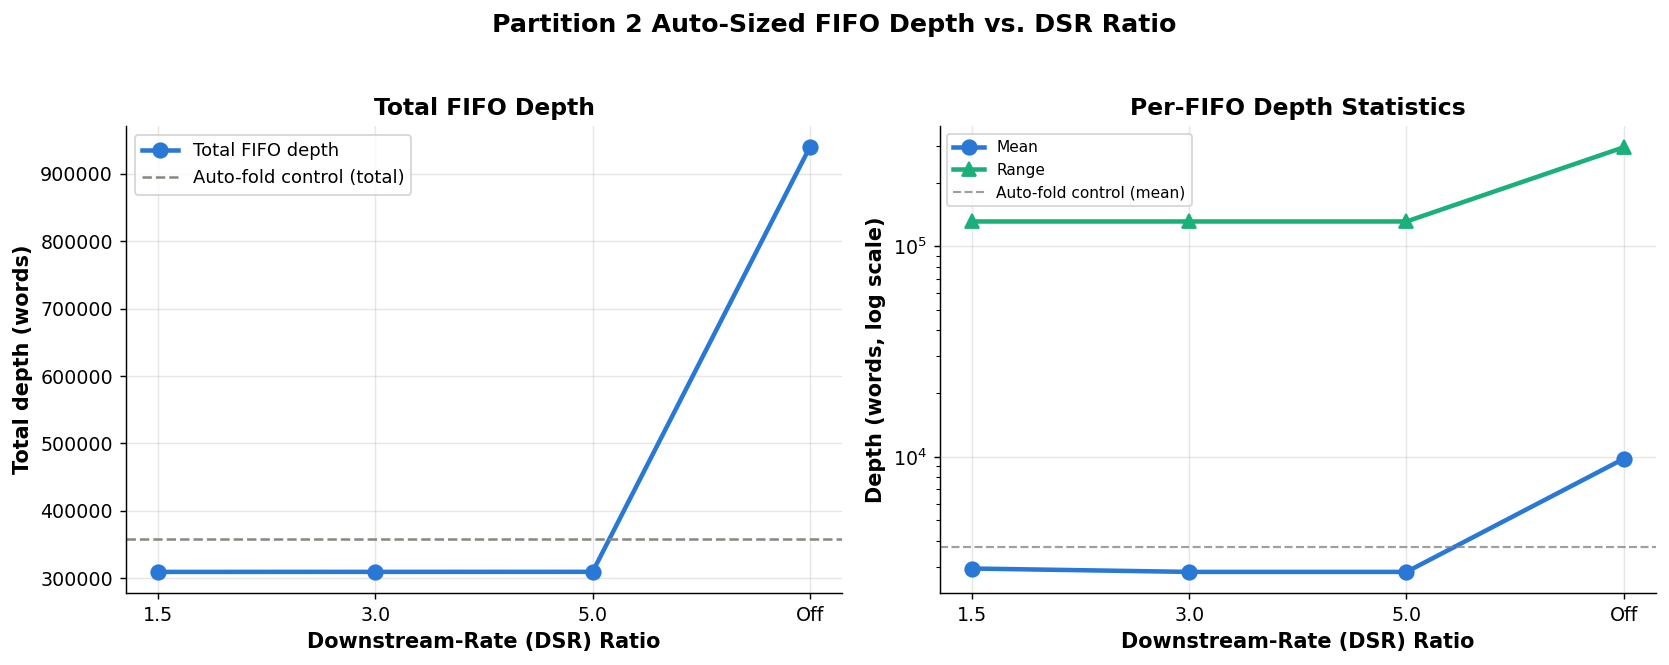

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fifo_depth_vs_dsr_ratio.png


In [7]:
plot_sweep(
    ["dsr1.5", "dsr3.0", "dsr5.0", "both_off"],
    "Downstream-Rate (DSR) Ratio",
    FIG_DIR / "partition2_fifo_depth_vs_dsr_ratio.png",
    "Partition 2 Auto-Sized FIFO Depth vs. DSR Ratio",
)


## Plot 1b: same, `Off` control point dropped

Zoomed in on just the three constrained `--dsr-ratio` points (`1.5/3.0/5.0`) --
the unconstrained `both_off` control (and its huge total/range, which
otherwise dominates the y-scale) is left out entirely.


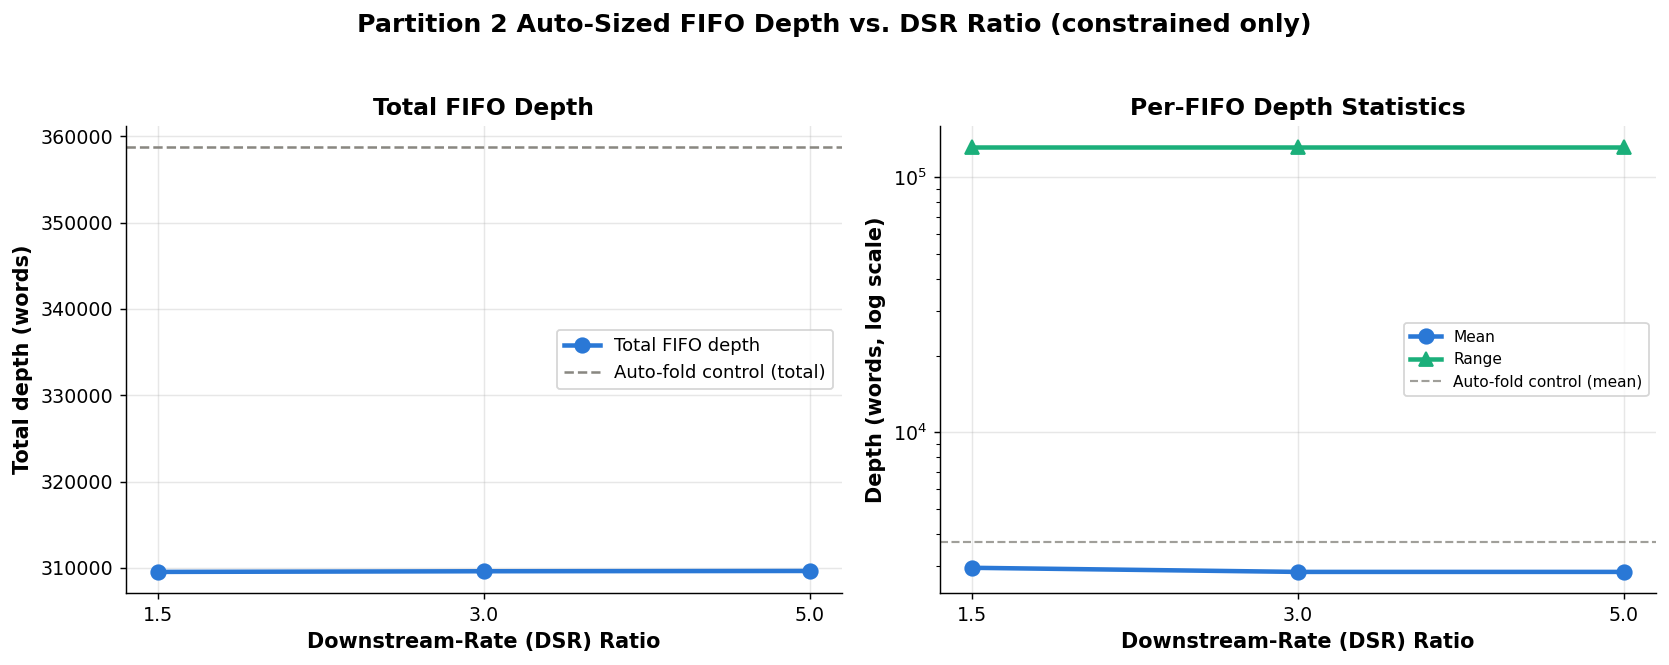

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fifo_depth_vs_dsr_ratio_no_off.png


In [8]:
plot_sweep(
    ["dsr1.5", "dsr3.0", "dsr5.0"],
    "Downstream-Rate (DSR) Ratio",
    FIG_DIR / "partition2_fifo_depth_vs_dsr_ratio_no_off.png",
    "Partition 2 Auto-Sized FIFO Depth vs. DSR Ratio (constrained only)",
)


## Plot 2: FIFO depth vs. `--pbi-ratio`

Only one hardware-validated `--pbi-ratio` point exists in this probe set
(`1.5`), so this is a two-point line against the same `both_off` control --
plotted as-is rather than implying a denser sweep than what was actually run
(`--dsr-ratio` is unconstrained throughout). `1.5` (constrained) comes before
`Off` (unconstrained), same direction as Plot 1.


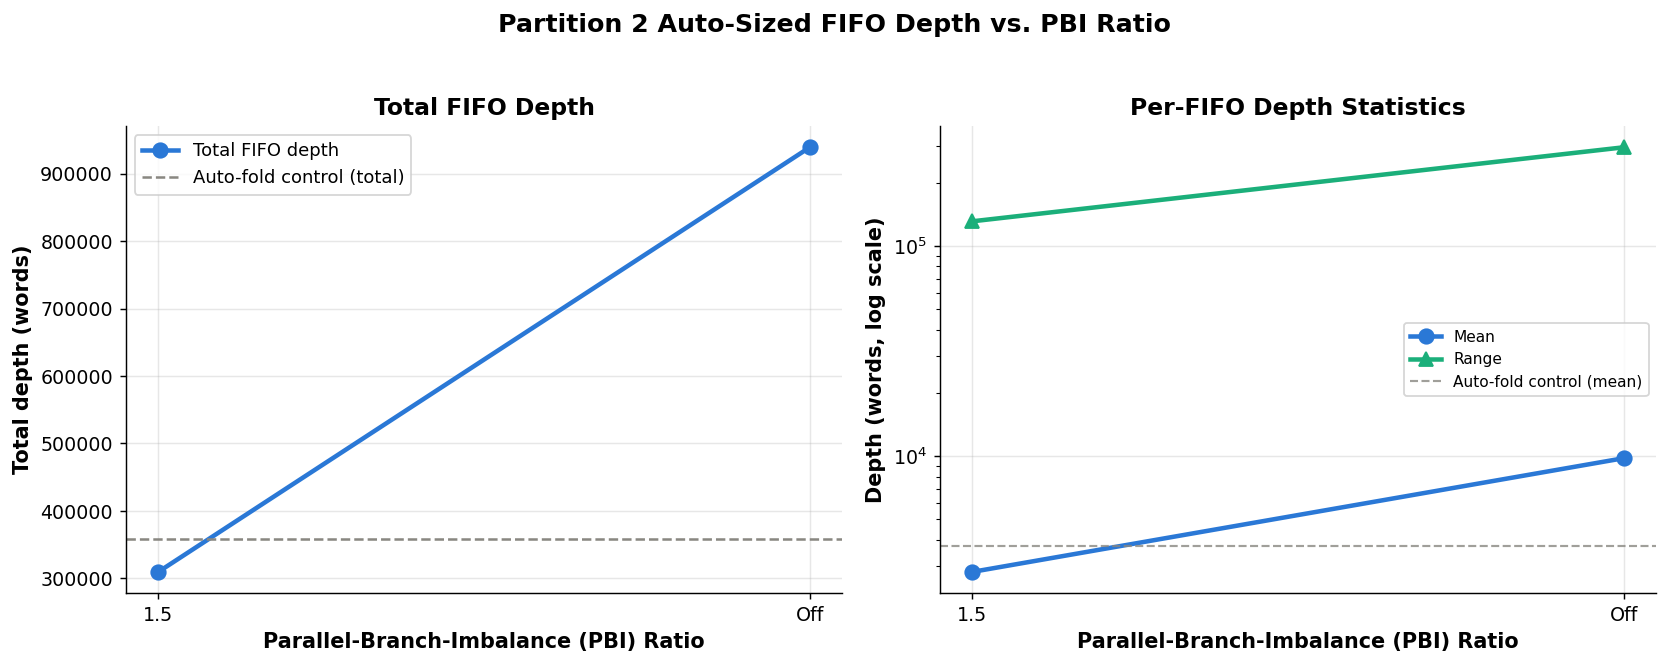

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fifo_depth_vs_pbi_ratio.png


In [9]:
plot_sweep(
    ["pbi1.5", "both_off"],
    "Parallel-Branch-Imbalance (PBI) Ratio",
    FIG_DIR / "partition2_fifo_depth_vs_pbi_ratio.png",
    "Partition 2 Auto-Sized FIFO Depth vs. PBI Ratio",
)


## Plot 2b: same, `Off` control point dropped

Only the single `--pbi-ratio 1.5` point remains -- a lone marker, not a line
(no second constrained point exists in this probe set to draw a trend
through).


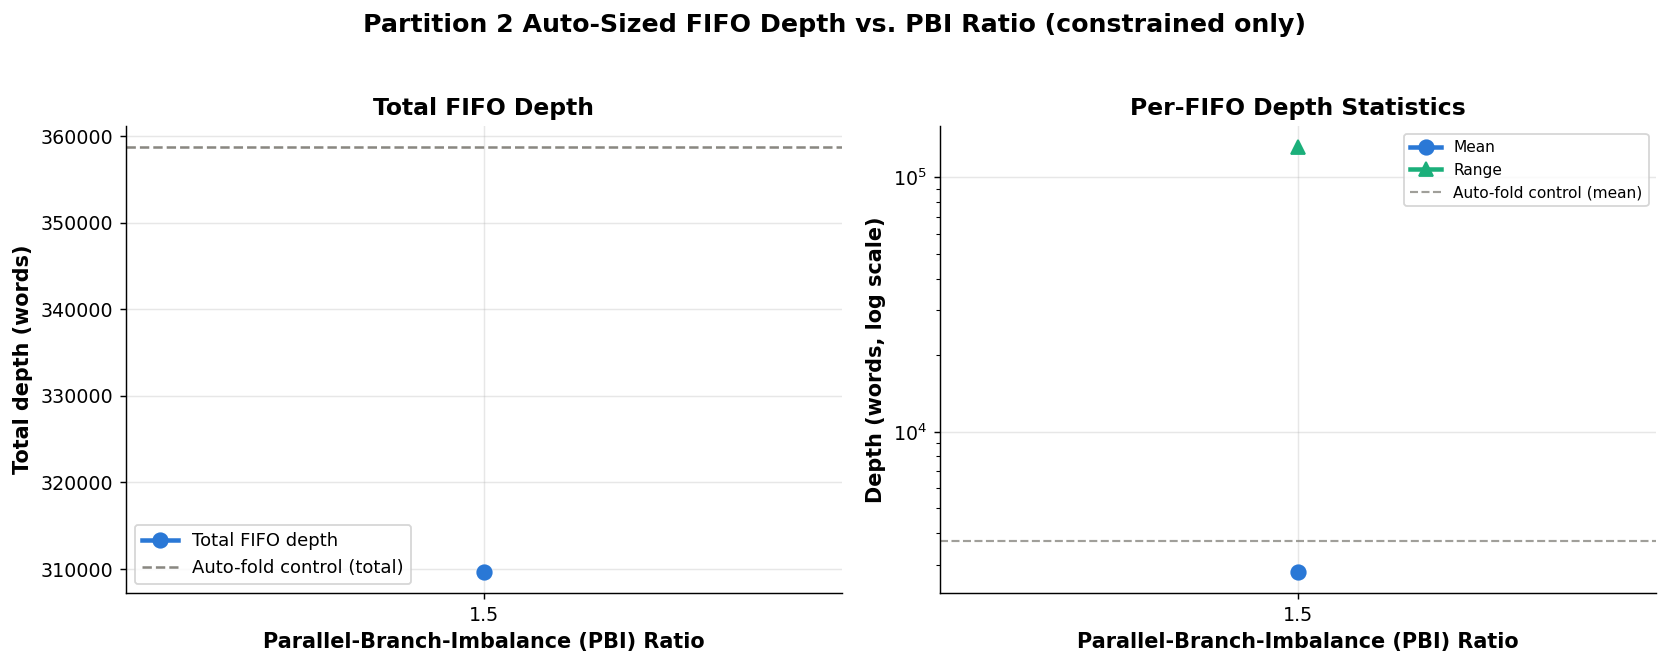

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fifo_depth_vs_pbi_ratio_no_off.png


In [10]:
plot_sweep(
    ["pbi1.5"],
    "Parallel-Branch-Imbalance (PBI) Ratio",
    FIG_DIR / "partition2_fifo_depth_vs_pbi_ratio_no_off.png",
    "Partition 2 Auto-Sized FIFO Depth vs. PBI Ratio (constrained only)",
)


## Plot 2c/2d: total bits and BRAM18K-equivalent vs. `--dsr-ratio` / `--pbi-ratio`

Same two-panel layout and x-axis convention as the depth plots above, but
converted via the previous section: left panel is total bits (log scale --
`Off`'s total is ~9x any constrained point, same order of magnitude jump as
the raw depth plot), right panel is BRAM18K-equivalent blocks (the
aspect-ratio-aware estimate as a solid line, the naive theoretical minimum
as a dotted line of the same color, so the packing-inefficiency gap between
them is visible directly rather than needing a separate table).


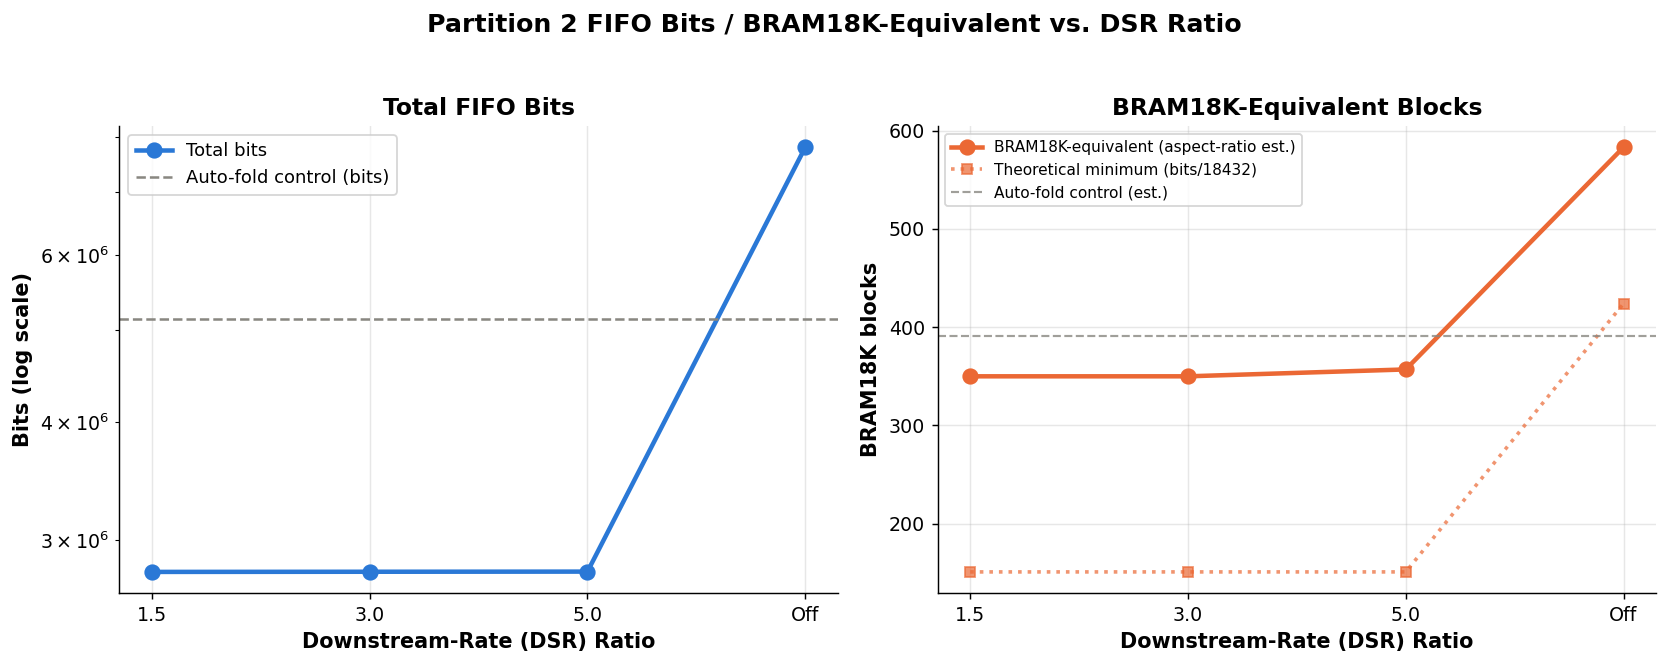

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fifo_bits_vs_dsr_ratio.png


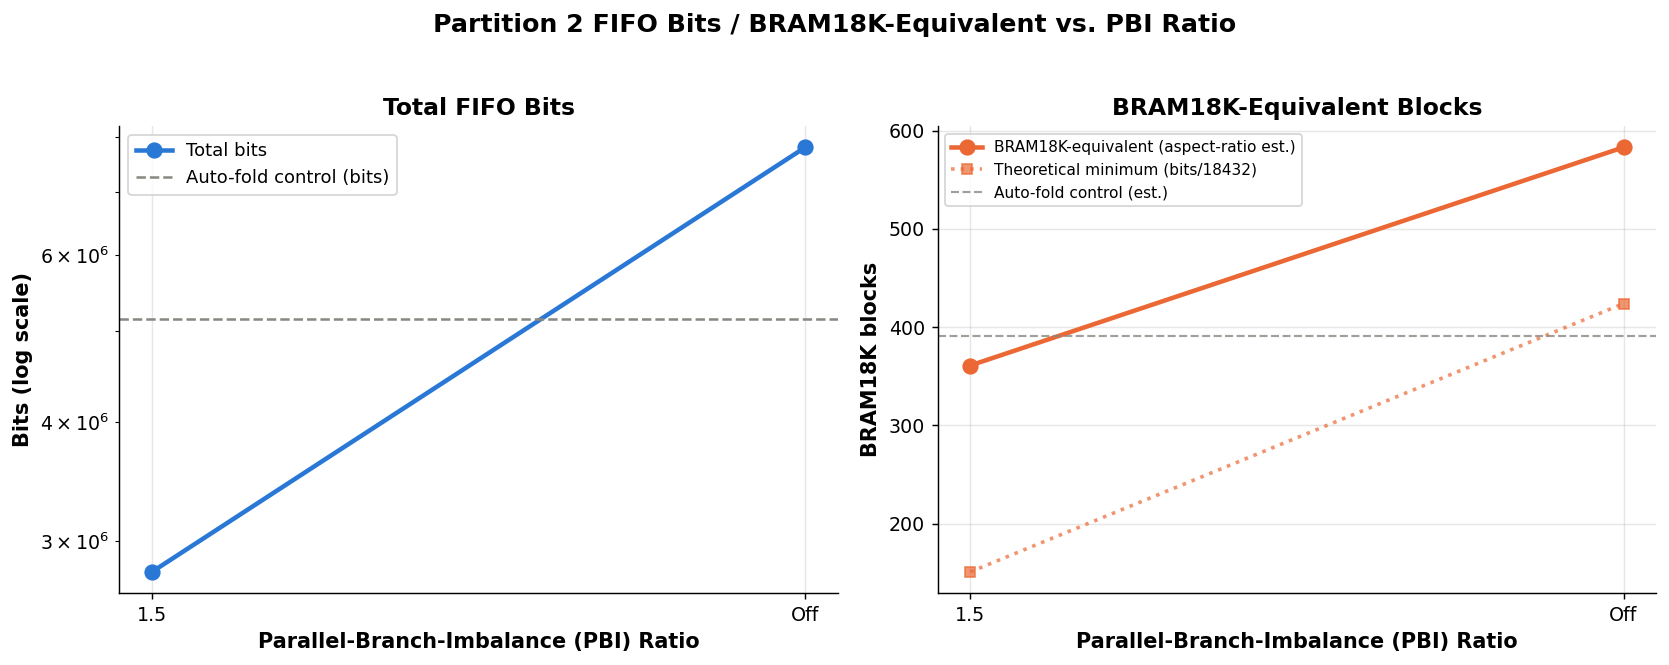

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fifo_bits_vs_pbi_ratio.png


In [11]:
def plot_bits_sweep(tags_in_order, x_axis_title, out_path, fig_title):
    xs = [stats[t]["x_label"] for t in tags_in_order]
    bits = [stats[t]["total_bits"] for t in tags_in_order]
    bram_est = [stats[t]["bram18k_est"] for t in tags_in_order]
    bram_min = [stats[t]["bram18k_theoretical_min"] for t in tags_in_order]
    af = stats["autofold_control"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

    axes[0].plot(xs, bits, marker="o", linewidth=2.5, markersize=8, color=COLOR_BITS, label="Total bits")
    axes[0].axhline(af["total_bits"], color=COLOR_AUTOFOLD, linestyle="--", linewidth=1.4,
                     label="Auto-fold control (bits)")
    axes[0].set_yscale("log")
    axes[0].set_title("Total FIFO Bits")
    axes[0].set_xlabel(x_axis_title)
    axes[0].set_ylabel("Bits (log scale)")
    axes[0].legend(frameon=True)

    axes[1].plot(xs, bram_est, marker="o", linewidth=2.5, markersize=8, color=COLOR_BRAM_EQUIV,
                 label="BRAM18K-equivalent (aspect-ratio est.)")
    axes[1].plot(xs, bram_min, marker="s", linestyle=":", linewidth=2, markersize=6, color=COLOR_BRAM_EQUIV,
                 alpha=0.7, label="Theoretical minimum (bits/18432)")
    axes[1].axhline(af["bram18k_est"], color=COLOR_AUTOFOLD, linestyle="--", linewidth=1.2, alpha=0.8,
                     label="Auto-fold control (est.)")
    axes[1].set_title("BRAM18K-Equivalent Blocks")
    axes[1].set_xlabel(x_axis_title)
    axes[1].set_ylabel("BRAM18K blocks")
    axes[1].legend(frameon=True, fontsize=8.5)

    fig.suptitle(fig_title, fontweight="bold", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path}")


plot_bits_sweep(
    ["dsr1.5", "dsr3.0", "dsr5.0", "both_off"],
    "Downstream-Rate (DSR) Ratio",
    FIG_DIR / "partition2_fifo_bits_vs_dsr_ratio.png",
    "Partition 2 FIFO Bits / BRAM18K-Equivalent vs. DSR Ratio",
)
plot_bits_sweep(
    ["pbi1.5", "both_off"],
    "Parallel-Branch-Imbalance (PBI) Ratio",
    FIG_DIR / "partition2_fifo_bits_vs_pbi_ratio.png",
    "Partition 2 FIFO Bits / BRAM18K-Equivalent vs. PBI Ratio",
)


## Achieved FPS vs. `--dsr-ratio` / `--pbi-ratio`

The FIFO-depth plots above show total/range collapsing to the SAME value the
instant any ratio constraint is applied (`1.5`, `3.0`, and `5.0` are
indistinguishable), which looks like the constraint acts as an on/off switch
rather than a continuous dial. Achieved FPS is the other half of that
picture: `Off` is bottlenecked by `MVAU_rtl_10` at 2,359,296 cycles (42.4
FPS @ 100 MHz), while every constrained point (`1.5`/`3.0`/`5.0`/`pbi1.5`)
is bottlenecked by a completely different node,
`ConvolutionInputGenerator_rtl_3`, at the identical 319,752 cycles
(312.7 FPS) -- confirming the switch-like behavior is real, not a FIFO-depth
artifact: the very first binding constraint moves the MILP off whichever
node was causing the unconstrained solve's severe slowdown, and once off
it, tightening further (`5.0 -> 1.5`) has no further effect because a
*different* node is now the bottleneck and neither ratio is currently
constraining IT.

No separate cost-model reconstruction is needed for `autofold_control`:
FINN's own characterization pass already wrote a real `cycles_estimate`
attribute onto every compute node in ALL SIX checkpoints (including
auto-fold), not just the five MILP-folded ones -- see the extraction cell
above. `autofold_control` lands at 393,216 cycles (254.3 FPS), bottlenecked
by yet a third node, `MVAU_rtl_1` -- worse than any DSR/PBI-constrained
point, better than the unconstrained MILP solve.


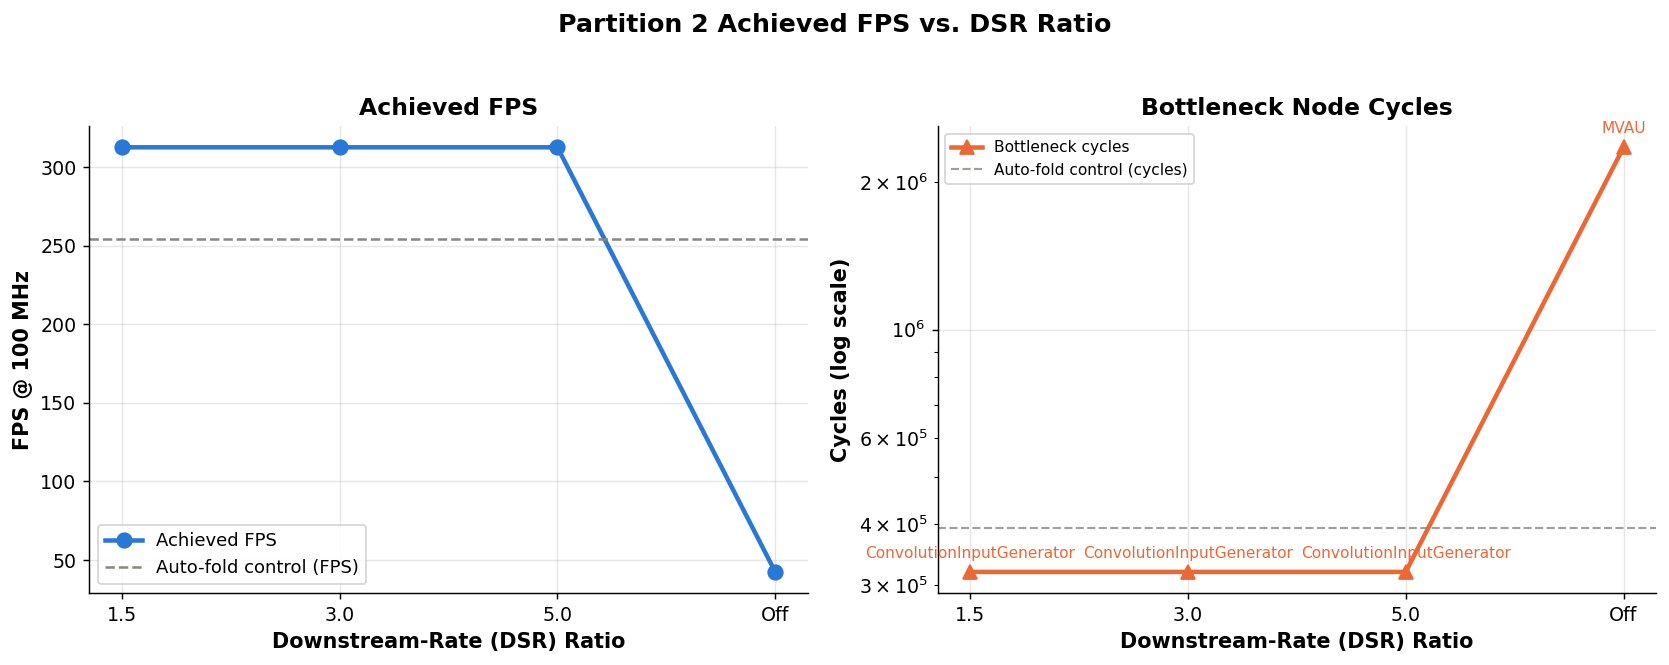

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fps_vs_dsr_ratio.png


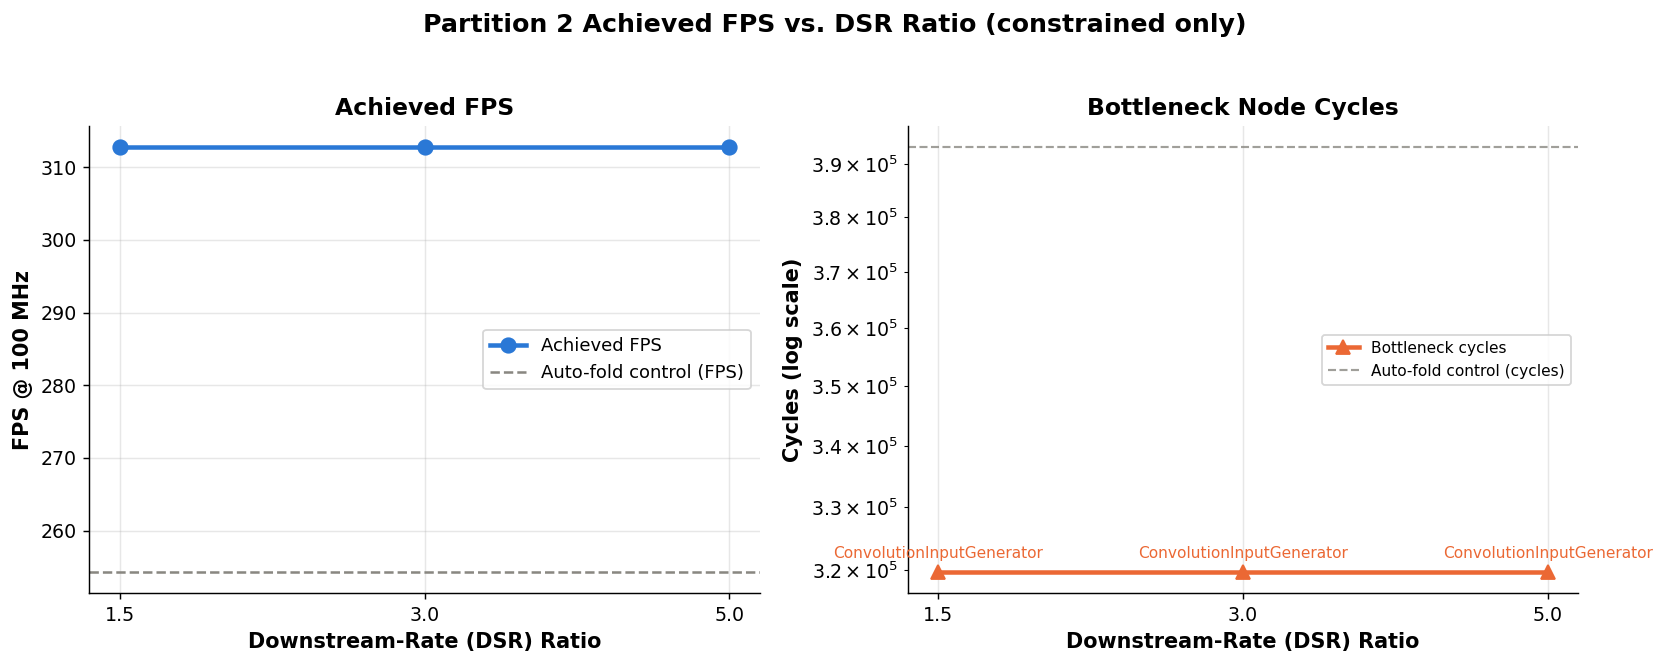

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fps_vs_dsr_ratio_no_off.png


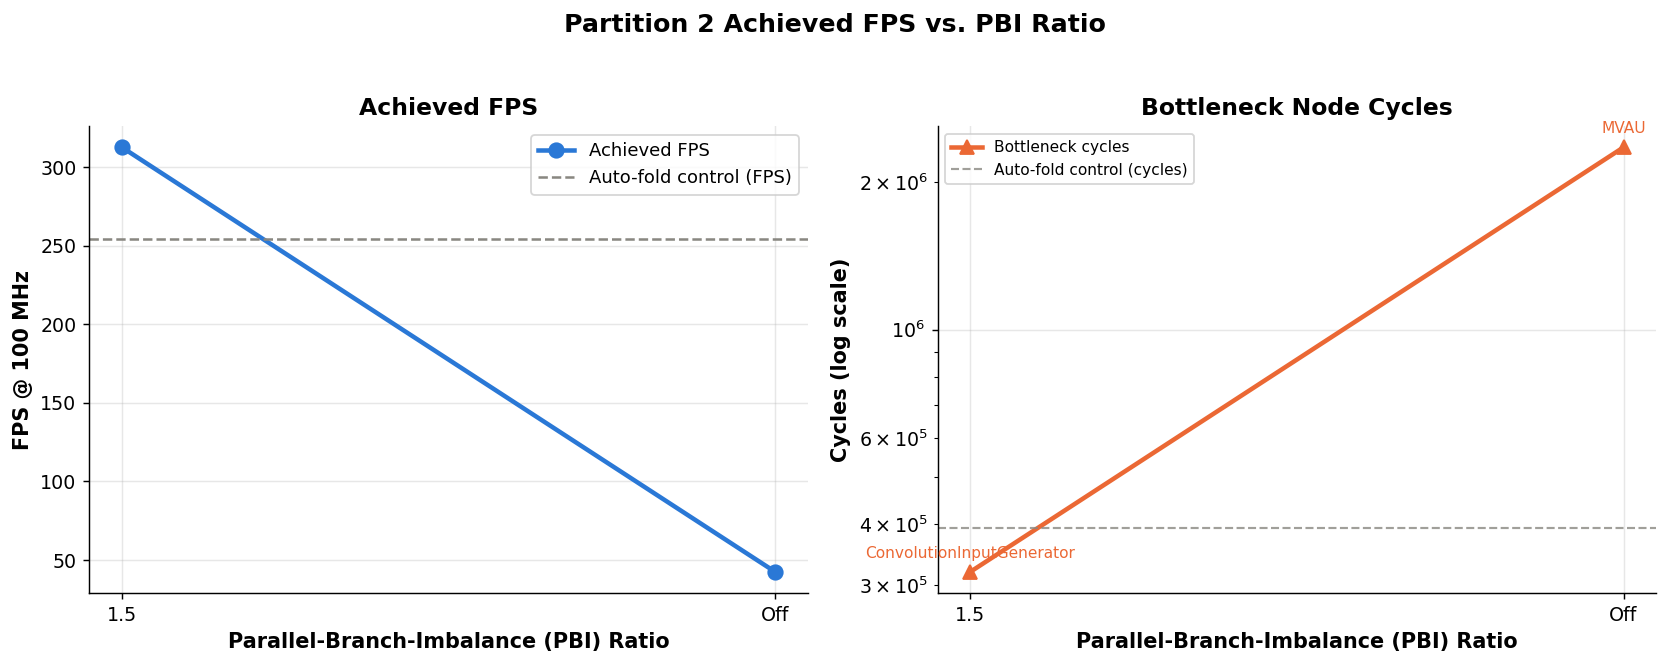

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fps_vs_pbi_ratio.png


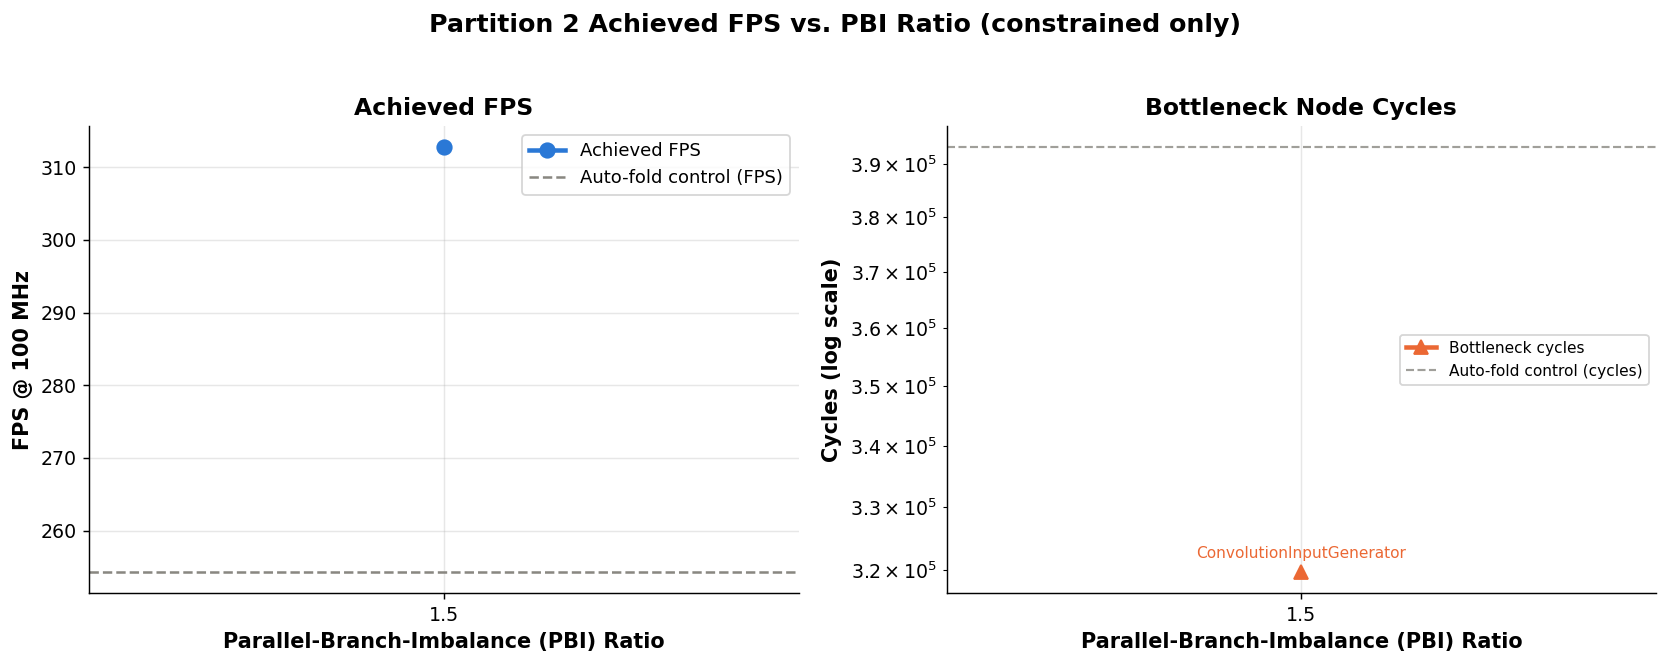

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_fps_vs_pbi_ratio_no_off.png


In [12]:
def plot_fps_sweep(tags_in_order, x_axis_title, out_path, fig_title):
    xs = [stats[t]["x_label"] for t in tags_in_order]
    fpses = [stats[t]["fps"] for t in tags_in_order]
    cycles = [stats[t]["bottleneck_cycles"] for t in tags_in_order]
    ops = [stats[t]["bottleneck_op"].replace("_rtl", "").replace("_hls", "") for t in tags_in_order]
    af = stats["autofold_control"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

    axes[0].plot(xs, fpses, marker="o", linewidth=2.5, markersize=8, color=COLOR_FPS, label="Achieved FPS")
    axes[0].axhline(af["fps"], color=COLOR_AUTOFOLD, linestyle="--", linewidth=1.4,
                     label="Auto-fold control (FPS)")
    axes[0].set_title("Achieved FPS")
    axes[0].set_xlabel(x_axis_title)
    axes[0].set_ylabel(f"FPS @ {CLOCK_MHZ:.0f} MHz")
    axes[0].legend(frameon=True)

    axes[1].plot(xs, cycles, marker="^", linewidth=2.5, markersize=8, color=COLOR_CYCLES,
                 label="Bottleneck cycles")
    axes[1].axhline(af["bottleneck_cycles"], color=COLOR_AUTOFOLD, linestyle="--", linewidth=1.2, alpha=0.8,
                     label="Auto-fold control (cycles)")
    for x, y, op in zip(xs, cycles, ops):
        axes[1].annotate(op, (x, y), xytext=(0, 8), textcoords="offset points",
                          ha="center", fontsize=8.5, color=COLOR_CYCLES)
    axes[1].set_yscale("log")
    axes[1].set_title("Bottleneck Node Cycles")
    axes[1].set_xlabel(x_axis_title)
    axes[1].set_ylabel("Cycles (log scale)")
    axes[1].legend(frameon=True, fontsize=8.5)

    fig.suptitle(fig_title, fontweight="bold", fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path}")


plot_fps_sweep(
    ["dsr1.5", "dsr3.0", "dsr5.0", "both_off"],
    "Downstream-Rate (DSR) Ratio",
    FIG_DIR / "partition2_fps_vs_dsr_ratio.png",
    "Partition 2 Achieved FPS vs. DSR Ratio",
)
plot_fps_sweep(
    ["dsr1.5", "dsr3.0", "dsr5.0"],
    "Downstream-Rate (DSR) Ratio",
    FIG_DIR / "partition2_fps_vs_dsr_ratio_no_off.png",
    "Partition 2 Achieved FPS vs. DSR Ratio (constrained only)",
)
plot_fps_sweep(
    ["pbi1.5", "both_off"],
    "Parallel-Branch-Imbalance (PBI) Ratio",
    FIG_DIR / "partition2_fps_vs_pbi_ratio.png",
    "Partition 2 Achieved FPS vs. PBI Ratio",
)
plot_fps_sweep(
    ["pbi1.5"],
    "Parallel-Branch-Imbalance (PBI) Ratio",
    FIG_DIR / "partition2_fps_vs_pbi_ratio_no_off.png",
    "Partition 2 Achieved FPS vs. PBI Ratio (constrained only)",
)


## Cross-checking the auto-fold control

`autofold_control`'s 254.3 FPS above comes from the checkpoint's own baked-in
`cycles_estimate` attribute (FINN's real characterization). Two independent
cross-checks of that number, using files this build already produced:

1. **The real folding FINN chose.** `autofold_config_partition2.json` (FINN's
   `step_target_fps_parallelization` output, committed alongside this build)
   is the actual PE/SIMD assignment applied -- confirm it agrees with what's
   baked into the checkpoint at the bottleneck node.
2. **An independent cost-model estimate.** `MILP/utils/apply_folding_config_cost.py`
   (new -- see its own docstring) applies that same folding_config.json's
   PE/SIMD to every node's real geometry/datatypes (read straight off the
   checkpoint) and prices them with this repo's own `finn_cost_model.py`
   formulas, rather than trusting FINN's characterization alone. It reproduces
   393,216 cycles / 254.31 FPS exactly (0.0% error on every node, validated
   against `both_off`'s baked-in folding too -- see the script's own
   docstring), AND additionally reports LUT/BRAM18K/DSP for `autofold_control`
   -- resource numbers FINN's own auto-fold characterization never produces on
   its own outside a full Vivado synth, and that this build's own `results.csv`
   collection has not gathered yet for this sweep.


In [13]:
with open(BUILD_DIR / "autofold_config_partition2.json") as f:
    autofold_config = json.load(f)

bottleneck_name = stats["autofold_control"]["bottleneck_name"]
autofold_model = onnx.load(str(CKPT_DIR / CHECKPOINTS["autofold_control"][0]))
bottleneck_node = next(n for n in autofold_model.graph.node if n.name == bottleneck_name)
baked_in = {a.name: a.i for a in bottleneck_node.attribute if a.name in ("PE", "SIMD")}

print(f"autofold_control's own bottleneck node: {bottleneck_name}")
print(f"  Baked into checkpoint (real, as-built): {baked_in}")
print(f"  autofold_config_partition2.json entry:  {autofold_config.get(bottleneck_name)}")
assert autofold_config.get(bottleneck_name) == baked_in, \
    "autofold_config_partition2.json's bottleneck-node entry does not match the checkpoint's baked-in PE/SIMD -- re-check."
print("CONFIRMED: FINN's own real folding_config.json agrees with the checkpoint's baked-in bottleneck-node PE/SIMD.")


autofold_control's own bottleneck node: MVAU_rtl_1
  Baked into checkpoint (real, as-built): {'PE': 1, 'SIMD': 6}
  autofold_config_partition2.json entry:  {'PE': 1, 'SIMD': 6}
CONFIRMED: FINN's own real folding_config.json agrees with the checkpoint's baked-in bottleneck-node PE/SIMD.


In [14]:
import subprocess

result = subprocess.run(
    [_sys.executable, str(REPO_ROOT / "MILP" / "utils" / "apply_folding_config_cost.py"),
     "--onnx", str(CKPT_DIR / CHECKPOINTS["autofold_control"][0]),
     "--folding-config", str(BUILD_DIR / "autofold_config_partition2.json"),
     "--self-check"],
    capture_output=True, text=True, cwd=str(REPO_ROOT),
)
print(result.stdout[-1200:])
if result.returncode != 0:
    print(result.stderr)


  297128  297128  (+0.0%)
StreamingDataWidthConverter_rtl_23 StreamingDataWidthConverter_rtl          43          0.0         0          n/a                0
MVAU_rtl_13                      MVAU_rtl                                150          0.0         6       393216  393216  (+0.0%)
Thresholding_rtl_28              Thresholding_rtl                         70          0.0         0        32768   32768  (+0.0%)
StreamingDataWidthConverter_rtl_24 StreamingDataWidthConverter_rtl          16          0.0         0          n/a                0
MVAU_rtl_14                      MVAU_rtl                                235          0.0         4       262144  262144  (+0.0%)
Thresholding_rtl_29              Thresholding_rtl                         96          3.7         0       131072  131072  (+0.0%)
AddStreams_hls_4                 AddStreams_hls                          131          0.0         0       131072  131072  (+0.0%)

Total predicted LUT:   18188 (7.89% of 230400 budget)
Total

## Resource utilization (LUT / BRAM18K-compute / BRAM18K-FIFO / DSP %) vs. achieved FPS, all six builds

The achieved-FPS story above doesn't say what it COSTS to get there. Using
`apply_folding_config_cost.py` uniformly on all six checkpoints' own
baked-in PE/SIMD (no folding-config override needed -- each is already
priced at its own as-built folding, the same self-check mode validated
above) gives a partition-2-scoped LUT/BRAM/DSP % for every build on the same
footing -- unlike `finn_milp.py`'s own `_diagnostics.*_pct_of_budget`, which
is a WHOLE-NETWORK number (every partition, not just this one), not
comparable to a partition-2-only OOC synth result.

That compute-side `bram_pct` is ONLY the MVAU/VVAU weight-memory BRAM --
`apply_folding_config_cost.py` doesn't price `StreamingFIFO_rtl` at all (it
skips FIFOs by design, see its own docstring). The FIFO buffering's own
BRAM18K-equivalent cost (from "Converting FIFO depth to bits..." above) is a
COMPLETELY SEPARATE contributor to real on-chip BRAM demand, normalized here
to the same `% of XCZU7EV budget` units so it can sit directly next to the
compute-side bar: `bram_fifo_pct = 100 * bram18k_est / XCZU7EV["BRAM_18K"]`.


In [15]:
_sys.path.insert(0, str(REPO_ROOT / "MILP" / "utils"))
from apply_folding_config_cost import XCZU7EV, estimate as cost_estimate  # noqa: E402

for tag, (fname, _run_dir, _dsr, _pbi, _xlabel) in CHECKPOINTS.items():
    r = cost_estimate(CKPT_DIR / fname)
    bram_fifo_pct = 100 * stats[tag]["bram18k_est"] / XCZU7EV["BRAM_18K"]
    stats[tag].update(lut_pct=r["lut_pct"], bram_pct=r["bram_pct"], dsp_pct=r["dsp_pct"], bram_fifo_pct=bram_fifo_pct)
    print(f"{tag:18s} LUT%={r['lut_pct']:6.2f}  BRAM%(compute)={r['bram_pct']:6.2f}  "
          f"BRAM%(FIFO)={bram_fifo_pct:6.2f}  DSP%={r['dsp_pct']:6.2f}  FPS={stats[tag]['fps']:7.2f}")


both_off           LUT%=  8.22  BRAM%(compute)= 18.69  BRAM%(FIFO)= 93.43  DSP%=  3.30  FPS=  42.39
dsr1.5             LUT%= 11.05  BRAM%(compute)= 16.89  BRAM%(FIFO)= 56.09  DSP%= 20.37  FPS= 312.74
dsr3.0             LUT%= 10.99  BRAM%(compute)= 18.09  BRAM%(FIFO)= 56.09  DSP%= 19.91  FPS= 312.74
dsr5.0             LUT%= 11.68  BRAM%(compute)= 19.29  BRAM%(FIFO)= 57.21  DSP%= 20.83  FPS= 312.74
pbi1.5             LUT%= 11.25  BRAM%(compute)= 19.89  BRAM%(FIFO)= 57.85  DSP%= 17.36  FPS= 312.74
autofold_control   LUT%=  7.89  BRAM%(compute)= 16.30  BRAM%(FIFO)= 62.66  DSP%=  4.05  FPS= 254.31


## Plot 3: resource utilization vs. achieved FPS (grouped bar chart)

One bar group per build, FOUR bars per group -- LUT% / BRAM18K-compute% /
BRAM18K-FIFO% / DSP%, fixed color order held constant with every other
resource-colored plot in this notebook, with the FIFO bar placed immediately
next to its compute-BRAM counterpart so the two BRAM sources are directly
comparable at a glance. X-axis ordered constrained-DSR -> constrained-PBI ->
unconstrained `Off` -> non-MILP `autofold_control` (same "constrained before
unconstrained" convention as every ratio plot above). Achieved FPS isn't a
bar (it isn't a resource-budget percentage, would need its own axis, and the
point here is resource COST, not throughput) -- it's printed above each
group instead, so the FPS a build achieves sits directly next to what it
paid in resources to get there, no legend lookup required.


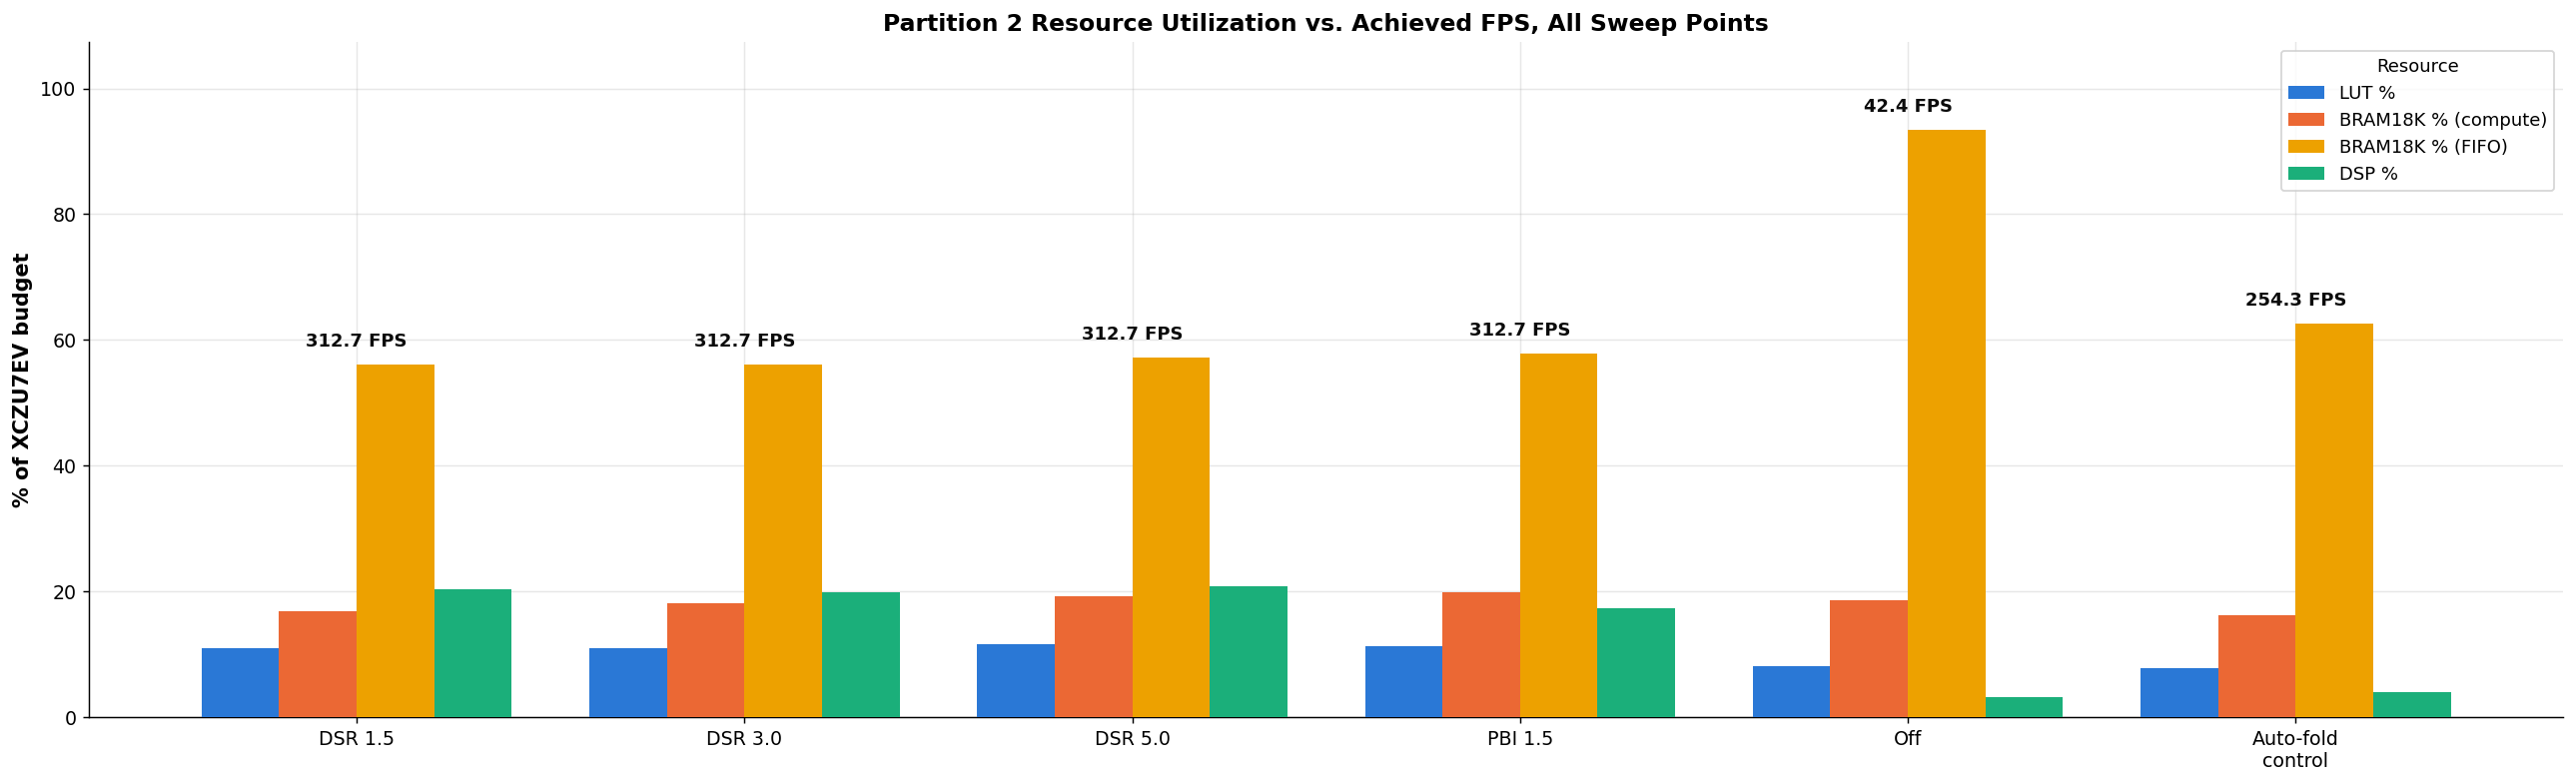

Wrote /workspace/LightM-UNet/analysis/report/MILP/FIFO/figures/partition2_resource_pct_vs_fps.png


In [16]:
def plot_resource_bars(tags_in_order, out_path, fig_title):
    n = len(tags_in_order)
    x = range(n)
    width = 0.2
    lut = [stats[t]["lut_pct"] for t in tags_in_order]
    bram = [stats[t]["bram_pct"] for t in tags_in_order]
    bram_fifo = [stats[t]["bram_fifo_pct"] for t in tags_in_order]
    dsp = [stats[t]["dsp_pct"] for t in tags_in_order]
    fps = [stats[t]["fps"] for t in tags_in_order]
    label_overrides = {
        "dsr1.5": "DSR 1.5", "dsr3.0": "DSR 3.0", "dsr5.0": "DSR 5.0", "pbi1.5": "PBI 1.5",
        "both_off": "Off", "autofold_control": "Auto-fold\ncontrol",
    }
    labels = [label_overrides[t] for t in tags_in_order]

    fig, ax = plt.subplots(figsize=(3.0 * n + 2, 6.2))
    ax.bar([i - 1.5 * width for i in x], lut, width, color=COLOR_LUT, label="LUT %", zorder=3)
    ax.bar([i - 0.5 * width for i in x], bram, width, color=COLOR_BRAM, label="BRAM18K % (compute)", zorder=3)
    ax.bar([i + 0.5 * width for i in x], bram_fifo, width, color=COLOR_BRAM_FIFO, label="BRAM18K % (FIFO)", zorder=3)
    ax.bar([i + 1.5 * width for i in x], dsp, width, color=COLOR_DSP, label="DSP %", zorder=3)

    for i, f in zip(x, fps):
        top = max(lut[i], bram[i], bram_fifo[i], dsp[i])
        ax.annotate(f"{f:.1f} FPS", (i, top), xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=10, fontweight="bold", color="#0b0b0b")

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylabel("% of XCZU7EV budget")
    ax.set_title(fig_title)
    ax.legend(frameon=True, title="Resource")
    ax.margins(y=0.15)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path}")


plot_resource_bars(
    ["dsr1.5", "dsr3.0", "dsr5.0", "pbi1.5", "both_off", "autofold_control"],
    FIG_DIR / "partition2_resource_pct_vs_fps.png",
    "Partition 2 Resource Utilization vs. Achieved FPS, All Sweep Points",
)


## Interpretation

Read the two summary numbers below together with the printed constraint
confirmation above: any change in FIFO depth or FPS across the DSR/PBI
sweep is attributable to the ratio constraint alone, not to a drifting
LUT/BRAM/DSP budget or bit-width search space.


In [17]:
both_off = stats["both_off"]
print("both_off (control): total={total}  mean={mean:.1f}  range={range}  "
      "bottleneck={bottleneck_cycles} ({bottleneck_op})  FPS={fps:.2f}".format(**both_off))
for tag in ("dsr1.5", "dsr3.0", "dsr5.0", "pbi1.5"):
    s = stats[tag]
    d_total = s["total"] - both_off["total"]
    d_fps = s["fps"] - both_off["fps"]
    print(f"{tag:8s}: total={s['total']:6d} ({d_total:+6d} vs control)   "
          f"bottleneck={s['bottleneck_cycles']:8d} ({s['bottleneck_op']:28s})   "
          f"FPS={s['fps']:7.2f} ({d_fps:+7.2f} vs control)")

af = stats["autofold_control"]
print(f"\nautofold_control (non-MILP-folded, not a sweep point): "
      f"total={af['total']}  mean={af['mean']:.1f}  range={af['range']}  "
      f"bottleneck={af['bottleneck_cycles']} ({af['bottleneck_op']})  FPS={af['fps']:.2f}")

print("\nResource cost of the FPS jump (dsr1.5 vs both_off control):")
d1 = stats["dsr1.5"]
print(f"  LUT%           {both_off['lut_pct']:.2f} -> {d1['lut_pct']:.2f}")
print(f"  BRAM% compute  {both_off['bram_pct']:.2f} -> {d1['bram_pct']:.2f}")
print(f"  BRAM% FIFO     {both_off['bram_fifo_pct']:.2f} -> {d1['bram_fifo_pct']:.2f}")
print(f"  DSP%           {both_off['dsp_pct']:.2f} -> {d1['dsp_pct']:.2f}  ({d1['fps']/both_off['fps']:.1f}x the FPS)")

print("\nFIFO memory cost (bits / BRAM18K-equivalent), dsr1.5 vs both_off control:")
print(f"  total_bits       {both_off['total_bits']:9d} -> {d1['total_bits']:9d}")
print(f"  bram18k_est      {both_off['bram18k_est']:5d} -> {d1['bram18k_est']:5d}")
print(f"  theoretical_min  {both_off['bram18k_theoretical_min']:5d} -> {d1['bram18k_theoretical_min']:5d}")

print("\nBRAM18K budget share, FIFO buffering vs. compute (weight memory), both_off control:")
print(f"  compute: {both_off['bram_pct']:.2f}%   FIFO: {both_off['bram_fifo_pct']:.2f}%  "
      f"({'FIFO' if both_off['bram_fifo_pct'] > both_off['bram_pct'] else 'compute'} dominates)")


both_off (control): total=938961  mean=9780.8  range=294910  bottleneck=2359296 (MVAU_rtl)  FPS=42.39
dsr1.5  : total=309532 (-629429 vs control)   bottleneck=  319752 (ConvolutionInputGenerator_rtl)   FPS= 312.74 (+270.36 vs control)
dsr3.0  : total=309608 (-629353 vs control)   bottleneck=  319752 (ConvolutionInputGenerator_rtl)   FPS= 312.74 (+270.36 vs control)
dsr5.0  : total=309641 (-629320 vs control)   bottleneck=  319752 (ConvolutionInputGenerator_rtl)   FPS= 312.74 (+270.36 vs control)
pbi1.5  : total=309672 (-629289 vs control)   bottleneck=  319752 (ConvolutionInputGenerator_rtl)   FPS= 312.74 (+270.36 vs control)

autofold_control (non-MILP-folded, not a sweep point): total=358712  mean=3736.6  range=131070  bottleneck=393216 (MVAU_rtl)  FPS=254.31

Resource cost of the FPS jump (dsr1.5 vs both_off control):
  LUT%           8.22 -> 11.05
  BRAM% compute  18.69 -> 16.89
  BRAM% FIFO     93.43 -> 56.09
  DSP%           3.30 -> 20.37  (7.4x the FPS)

FIFO memory cost (bits /